# RL Network-Markowitz Portfolio Optimization
### Thesis-Ready Version — Multi-Seed SAC + Ablation Study (5000 Steps) + Sortino Monitoring

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import shap
import torch
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback
from tqdm.notebook import tqdm
from scipy import stats
from scipy.optimize import minimize
from IPython.display import Image, display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ================================================================
# GLOBAL SETTINGS
# ================================================================
SEEDS         = [42, 123, 77]
TRAIN_STEPS   = 5000
FORCE_RETRAIN = True
GAMMA_CENTER  = 0
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20
CVAR_LEVEL    = 0.95
STAT_ALPHA    = 0.05
SAVE_IMAGES   = False

ABLATION_CONFIGS = {
    'E2_Sharpe'          : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'sharpe'},
    'E2_Sortino'         : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'sortino'},
    'E2_Calmar'          : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'calmar'},
    'E2_Ulcer'           : {'use_network': True,  'use_market': True,  'extra_features': [], 'reward_type': 'ulcer'},
    'E2_Ensemble_Avg'    : {'use_network': True,  'use_market': True,  'extra_features': [], 'is_ensemble': True},
    'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 0.0},
    'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 2.0},
}

EVAL_METRICS = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Ulcer Index']

OUTPUT_DIR = os.path.join(os.getcwd(), 'ablation_results_thesis_5000')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Environment initialized.')

Environment initialized.


In [2]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets: assets.remove('USDT')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets: {len(assets)}')
print(f'Training: {ret_train.index[0].date()} to {ret_train.index[-1].date()}')
print(f'Testing: {ret_test.index[0].date()} to {ret_test.index[-1].date()}')

Assets: 9
Training: 2017-09-15 to 2019-03-02
Testing: 2019-03-03 to 2019-10-17


In [3]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0: eigenvalues[:-1] = 0
    else: eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised

def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons_with_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1}, {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)})
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0, 1.0) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success: return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0

def _build_mst_centrality(N, corr_f):
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=300)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except: cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cent_vec

def fast_centrality_weights(cov_f, cent_vec, mu, gamma): return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))

def compute_classic_mv_weights(returns_window):
    T, N = returns_window.shape
    mu = returns_window.mean().values
    cov = np.cov(returns_window.values.T) + np.eye(N) * 1e-8
    w0 = np.ones(N) / N
    bounds = tuple((0.0, 1.0) for _ in range(N))
    fun = lambda w: w @ cov @ w
    cons_with_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1}, {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)})
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    return res.x if res.success else w0

In [4]:
def _compute_drawdown(arr):
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd = (cumulative - peak) / peak
    return dd, cumulative

def calculate_annualized_return(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    n = len(arr)
    if n == 0: return np.nan
    total = (1 + arr).prod()
    return total ** (periods_per_year / n) - 1 if total > 0 else np.nan

def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    return ann_ret / ann_vol if ann_vol > 0 else 0.0

def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    downside = arr[arr < mar]
    if len(downside) == 0: return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    return ann_ret / downside_dev if downside_dev > 0 else 0.0

def calculate_calmar_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    return ann_ret / abs(max_dd) if abs(max_dd) > 1e-8 else 0.0

def calculate_ulcer_index(ret_series):
    arr = np.array(ret_series)
    if len(arr) == 0: return 0.0
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd = (cumulative - peak) / peak
    return float(np.sqrt(np.mean(dd**2)))

def calculate_all_metrics(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    drawdown, _ = _compute_drawdown(arr)
    return {'Sharpe Ratio': calculate_sharpe_ratio(arr, periods_per_year), 'Sortino Ratio': calculate_sortino_ratio(arr, periods_per_year), 'Calmar Ratio': calculate_calmar_ratio(arr, periods_per_year), 'Ulcer Index': calculate_ulcer_index(arr), 'Max Drawdown': drawdown.min()}

In [5]:
def compute_network_features(returns_window):
    T, N = returns_window.shape
    corr_f = apply_rmt_filter(returns_window)
    mst, cent_vec = _build_mst_centrality(N, corr_f)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    spectral_gap = nx.algebraic_connectivity(mst)
    return np.array([mst_dist * 0.1, spectral_gap], dtype=np.float32), corr_f, cent_vec

def compute_market_features(returns_window):
    arr = returns_window.values
    T, N = arr.shape
    win5, win20 = max(1, min(5, T)), max(1, min(20, T))
    v5, v20 = arr[-win5:].std(axis=0).mean(), arr[-win20:].std(axis=0).mean()
    m5, m20 = arr[-win5:].mean(axis=0).mean(), arr[-win20:].mean(axis=0).mean()
    pct_up = float(np.mean(arr[-win5:].mean(axis=0) > arr[-win20:].mean(axis=0)))
    return np.array([v5*100, v20*100, v5/(v20+1e-8), m5*100, m20*100, (m5-m20)*100, pct_up], dtype=np.float32)

GLOBAL_CACHE = {}
print('Precomputing cache...')
for i in range(SET_WINDOW, len(ret_train)):
    win = ret_train.iloc[i-SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    GLOBAL_CACHE[i] = {'win': win, 'corr_f': corr, 'cent_vec': cent, 'cov_f': np.outer(win.std(), win.std())*corr + np.eye(len(assets))*1e-8, 'mu': win.mean().values, 'nw_feat_full': feat}
for i in range(SET_WINDOW, len(ret_test)):
    win = ret_test.iloc[i-SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    GLOBAL_CACHE[len(ret_train)+i] = {'win': win, 'corr_f': corr, 'cent_vec': cent, 'cov_f': np.outer(win.std(), win.std())*corr + np.eye(len(assets))*1e-8, 'mu': win.mean().values, 'nw_feat_full': feat}

FEAT_MEAN = np.stack([GLOBAL_CACHE[i]['nw_feat_full'] for i in sorted(GLOBAL_CACHE.keys()) if i < len(ret_train)]).mean(axis=0)
FEAT_STD  = np.stack([GLOBAL_CACHE[i]['nw_feat_full'] for i in sorted(GLOBAL_CACHE.keys()) if i < len(ret_train)]).std(axis=0) + 1e-8

def build_observation(win, config, nw_feat_raw=None, corr_f=None):
    if nw_feat_raw is None: nw_feat_raw, corr_f, _ = compute_network_features(win)
    obs = []
    if config['use_network']: obs.append((nw_feat_raw - FEAT_MEAN)/FEAT_STD)
    if config['use_market']: obs.append(compute_market_features(win))
    return np.nan_to_num(np.concatenate(obs)), corr_f

def get_obs_dim(config): return max((2 if config['use_network'] else 0) + (7 if config['use_market'] else 0), 1)

Precomputing cache...


In [6]:
class AblationPortfolioEnv(gym.Env):
    def __init__(self, data, config, data_start_offset=0):
        super().__init__()
        self.data, self.config, self.offset = data, config, data_start_offset
        self.current_step, self._returns_buffer, self._rew_stats = SET_WINDOW, [], {'mean': 0, 'M2': 0, 'count': 0}
        dim = get_obs_dim(config)
        self.action_space = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(dim,), dtype=np.float32)

    def _get_obs(self): idx = self.offset + self.current_step; c = GLOBAL_CACHE[idx]; obs, _ = build_observation(c['win'], self.config, c['nw_feat_full'], c['corr_f']); return obs

    def reset(self, seed=None, options=None): self.current_step, self._returns_buffer = SET_WINDOW, []; return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0))
        idx = self.offset + self.current_step; c = GLOBAL_CACHE[idx]
        w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > REWARD_WINDOW: self._returns_buffer.pop(0)
        arr = np.array(self._returns_buffer); reward_type = self.config.get('reward_type', 'calmar')
        if len(arr) < 2: raw_reward = port_ret * 100
        else:
            if reward_type == 'sharpe': raw_reward = float(np.clip(calculate_sharpe_ratio(arr), -10.0, 10.0))
            elif reward_type == 'sortino': raw_reward = float(np.clip(calculate_sortino_ratio(arr), -10.0, 10.0))
            elif reward_type == 'calmar': raw_reward = float(np.clip(calculate_calmar_ratio(arr), -10.0, 10.0))
            elif reward_type == 'ulcer': ulcer = calculate_ulcer_index(arr); raw_reward = float(np.clip(calculate_annualized_return(arr)/ulcer if ulcer > 1e-8 else 0, -10.0, 10.0))
            else: raw_reward = 0.0
        s = self._rew_stats; s['count'] += 1; d = raw_reward - s['mean']; s['mean'] += d / s['count']; s['M2'] += d * (raw_reward - s['mean'])
        std = np.sqrt(s['M2']/s['count']) if s['count'] > 1 else 1.0; reward = float(np.clip(raw_reward / (std + 1e-6), -10.0, 10.0))
        self.current_step += 1; done = self.current_step >= len(self.data) - 1
        return self._get_obs() if not done else np.zeros(self.observation_space.shape), reward, done, False, {}

class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards, self.step_rewards, self.current_episode_reward = [], [], 0
    def _on_step(self) -> bool:
        reward = self.locals['rewards'][0]; self.step_rewards.append(reward); self.current_episode_reward += reward
        if self.locals['dones'][0]: self.episode_rewards.append(self.current_episode_reward); self.current_episode_reward = 0
        return True

def plot_sortino_step_monitoring(step_rewards, exp_id, start_step=100, end_step=1000):
    plt.figure(figsize=(10, 5)); data_slice = step_rewards[start_step:end_step]; steps = range(start_step, start_step + len(data_slice))
    plt.plot(steps, data_slice, color='#9C27B0', alpha=0.6, label='Raw Step Reward')
    if len(data_slice) > 20: ma = pd.Series(data_slice).rolling(window=20).mean(); plt.plot(steps, ma, color='black', lw=2, label='Trend (MA 20)')
    plt.title(f'Monitoring Performa {exp_id}\nStep {start_step} sampai {end_step}', fontweight='bold'); plt.xlabel('Training Steps'); plt.ylabel('Normalized Sortino Score'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

Experiments:   0%|          | 0/8 [00:00<?, ?it/s]

Output()

Output()

Output()

Output()

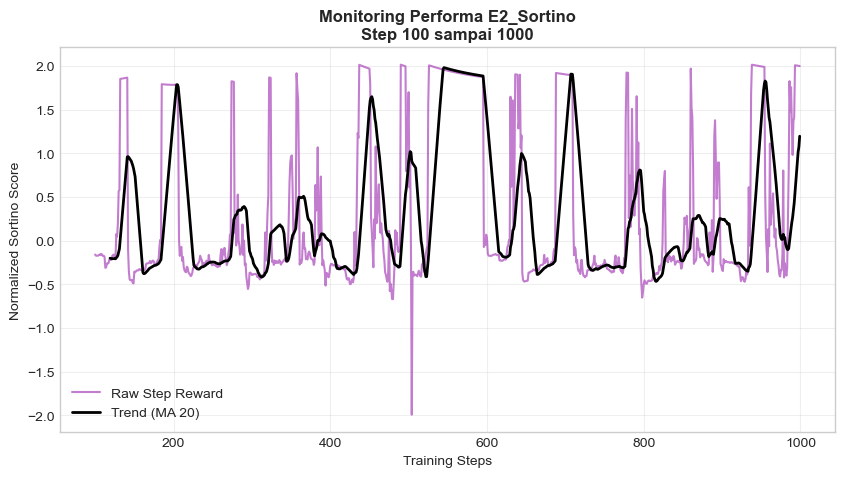

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

In [ ]:
trained_models, train_histories = {}, {}
for exp_id, config in tqdm(ABLATION_CONFIGS.items(), desc="Experiments"):
    if config.get('static_gamma') is not None or config.get('is_ensemble'): continue
    train_histories[exp_id] = {}
    for seed in SEEDS:
        name = f'model_{exp_id}_s{seed}'
        if os.path.exists(name + ".zip") and not FORCE_RETRAIN: trained_models[(exp_id, seed)] = name; continue
        env = AblationPortfolioEnv(ret_train, config, 0); callback = RewardLoggerCallback()
        model = SAC('MlpPolicy', env, seed=seed, verbose=0, learning_rate=3e-4)
        model.learn(total_timesteps=TRAIN_STEPS, callback=callback, progress_bar=True)
        model.save(name); trained_models[(exp_id, seed)] = name; train_histories[exp_id][seed] = callback.episode_rewards
        if exp_id == 'E2_Sortino' and seed == SEEDS[0]: plot_sortino_step_monitoring(callback.step_rewards, exp_id, 100, 1000)

In [ ]:
results_test = {}
for exp_id in list(ABLATION_CONFIGS.keys()) + ['Classic-MV']:
    results_test[exp_id] = pd.DataFrame(); config = ABLATION_CONFIGS.get(exp_id, {})
    for seed in SEEDS:
        model, ensemble_models = None, []
        if exp_id not in ['Classic-MV'] and config.get('static_gamma') is None:
            if config.get('is_ensemble'):
                for m_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']: ensemble_models.append(SAC.load(trained_models[(m_id, seed)]))
            else: model = SAC.load(trained_models[(exp_id, seed)])
        rets_test = []
        for i in range(SET_WINDOW, len(ret_test)):
            idx = len(ret_train) + i; c = GLOBAL_CACHE[idx]
            if exp_id == 'Classic-MV': w = compute_classic_mv_weights(c['win'])
            elif config.get('static_gamma') is not None: w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], config['static_gamma'])
            elif config.get('is_ensemble'):
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                gammas = [float(em.predict(obs, deterministic=True)[0][0]) for em in ensemble_models]
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], sum(gammas)/len(gammas))
            else:
                obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
                action, _ = model.predict(obs, deterministic=True)
                w = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], float(action[0]))
            rets_test.append(np.dot(w, ret_test.iloc[i].values))
        results_test[exp_id][seed] = pd.Series(rets_test, index=ret_test.index[SET_WINDOW:])

plt.figure(figsize=(12, 6))
for exp_id, df in results_test.items():
    avg_rets = df.mean(axis=1); cum_rets = (1 + avg_rets).cumprod(); plt.plot(cum_rets, label=exp_id)
plt.title(f'Cumulative Returns - {TRAIN_STEPS} Steps'); plt.legend(); plt.show()